## Задание 1. Создание нейросети в Scikit learn

Используя возможности библиотеки scikit learn разработайте простую нейронную сеть (многослойный персептрон), используя один из датасетов предложенных преподавателем или собственный датасет. При реализации задания необходимо выполнить следующие этапы:
подготовка обучающих данных;
создание нейросети;
подбор гиперпараметров с помощью GridSearchCV или RandomizedSearchCV;
обучение нейросети;
визуализация результатов и подсчет метрик качества.
*Примечание: для выполнения задания можно использовать возможности библиотек, изученных ранее (numpy, pandas, Matplotlib, seaborn).*

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие гиперпараметры: {'solver': 'sgd', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (50, 50), 'batch_size': 128, 'alpha': 0.0001, 'activation': 'relu'}
Отчет о классификации:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       317
           1       0.97      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

Точность (Accuracy): 0.9763


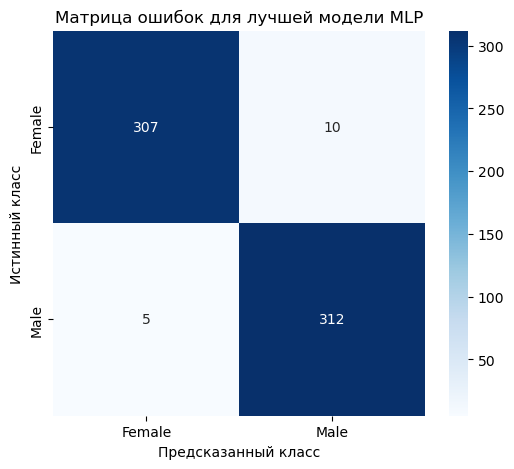

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

RANDOM_STATE = 42

df = pd.read_csv('voice.csv')

# male -> 1, female -> 0
df['label'] = df['label'].map({'male': 1, 'female': 0})

X = df.drop('label', axis=1)
y = df['label']

# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# базовый классификатор
mlp = MLPClassifier(random_state=RANDOM_STATE, max_iter=300, early_stopping=True)

# словарь, описывающий пространство гиперпараметров
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128]
}

# создание объекта RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=50,        # Количество случайных комбинаций
    cv=5,             # 5-кратная кросс-валидация
    scoring='accuracy',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# обучение и подбор гиперпараметров
random_search.fit(X_train_scaled, y_train)

# Вывод лучших параметров
print("Лучшие гиперпараметры:", random_search.best_params_)

# лучшая модель
best_mlp = random_search.best_estimator_

# предсказания на тестовой выборке
y_pred = best_mlp.predict(X_test_scaled)
y_pred_proba = best_mlp.predict_proba(X_test_scaled)[:, 1]  # Вероятности для класса 1

# метрики качества
print("Отчет о классификации:\n", classification_report(y_test, y_pred))
print("Точность (Accuracy): {:.4f}".format(accuracy_score(y_test, y_pred)))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Матрица ошибок для лучшей модели MLP')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

## Задание 2. Алгоритм обратного распространения ошибки

---

В данном задании Вам нужно будет:
- дополнить класс **`Neuron()`** с функцией активации ReLU, чтобы в нём было запрограмировано обучение нейронной сети по методу обратного распространения ошибки (прямой и обратный проход по сети)

- обучить и протестировать этот класс на сгенерированных и реальных данных

In [65]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

In [66]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---

В данном случае мы решаем задачу бинарной классификации (2 класса: 1 или 0). Для простоты в качестве функции потерь возьмём квадратичную функцию потерь, хоть она и плохо показывает себя в задаче классификации.

$$
Loss(\hat{y}, y) = \frac{1}{n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2
$$  

Здесь $w \cdot X_i$ - скалярное произведение, а $\hat{y_i} = \sigma(w \cdot X_i ), а \  \sigma$- функция активации ($i$ -- номер объекта в выборке).

In [67]:
def Loss(y_pred, y):
    y_pred = y_pred.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    return 0.5 * np.mean((y_pred - y) ** 2)

<h2 style="text-align: center;"><b>Нейрон с ReLU (Recitified Linear Unit)</b></h2>  

ReLU самая часто используемая (по крайней мере, пару лет назад) функция активации в нейронных сетях. Выглядит она очень просто:

\begin{equation*}
ReLU(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Или по-другому:

$$
ReLU(x) = \max(0, x)
$$

В (свободном) переводе Rectified Linear Unit = "Усечённая линейная функция". Собственно, мы по сути просто не даём проходить отрицательным числам.

Производная здесь берётся как производная от кусочно-заданной функции, то есть на участках, где функция гладкая, и в нуле её доопредляют нулём:

\begin{equation*}
ReLU'(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим ReLu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ReLU(w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
    y_i^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

(помните, что $w \cdot X_i$ -- это число в данном случае (результат скалярного произведения двух векторов)).

Тогда формула для обновления весов при градиентном спуске будет такая (в матричном виде, рекмендуем вывести самим то, как это получается из формулы для одного объекта):

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   0, &{w \cdot X_i \le 0}\\
   \frac{1}{n} X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

(напоминаем, что здесь $w \cdot X$ -- матричное произведение вектора $w$ (ведь вектор -- тоже матрица, не так ли?) и матрицы $X$ )

Почему в первом случае будет 0? Потому что в формулу $y_i^2$ не входят веса , а мы берём производную именно по весам $w$.

* Реализуйте ReLU и её производную:

In [33]:
def relu(x):
    """ReLU-функция"""
    return np.maximum(0, x)

In [34]:
def relu_derivative(x):
    """Производная ReLU"""
    return (x >= 0).astype(float)

Теперь нужно написать класс нейрон с ReLU:

In [48]:
class NeuronReLU:
    def __init__(self, w=None, b=0):
        """
        :param: w -- вектор весов
        :param: b -- смещение
        """
        self.w = w
        self.b = b


    def activate(self, x):
        return relu(x)


    def forward_pass(self, X):
        """
        Рассчитывает ответ нейрона при предъявлении набора объектов
        :param: X -- матрица примеров размера (n, m), каждая строка - отдельный объект
        :return: вектор размера (n, 1) из нулей и единиц с ответами нейрона
        """
        n = X.shape[0]
        y_pred = np.zeros((n, 1))  # y_pred == y_predicted - предсказанные классы
        z = np.dot(X, self.w) + self.b   
        y_pred = self.activate(z)
        return y_pred


    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        """
        Обновляет значения весов нейрона в соответствии с этим объектом
        :param: X -- матрица входов размера (n, m)
                y -- вектор правильных ответов размера (n, 1)
                learning_rate - "скорость обучения" (символ alpha в формулах выше)
        В этом методе ничего возвращать не нужно, только правильно поменять веса
        с помощью градиентного спуска.
        """
        n = len(y)
        y = np.array(y).reshape(-1, 1)
        z = np.dot(X, self.w) + self.b
        
        # производная ReLU в точке z
        relu_grad = relu_derivative(z)
        error = y_pred - y
        
        dw = (1.0 / n) * np.dot(X.T, error * relu_grad)
        db = (1.0 / n) * np.sum(error * relu_grad)
        
        self.w -= learning_rate * dw
        self.b -= learning_rate * db


    def fit(self, X, y, num_epochs=300):
        """
        Спускаемся в минимум
        :param: X -- матрица объектов размера (n, m)
                y -- вектор правильных ответов размера (n, 1)
                num_epochs -- количество итераций обучения
        :return: losses -- вектор значений функции потерь
        """
        n, m = X.shape
        #self.w = np.zeros((m, 1))
        #self.b = 0  # смещение (число)
        if self.w is None:
            self.w = np.random.randn(m, 1) * 0.01  # маленькие случайные числа
        if self.b is None:
            self.b = 0.0
        losses = []  # значения функции потерь на различных итерациях обновления весов
        
        for i in range(num_epochs):
            y_pred = self.forward_pass(X)
            losses.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred)

        return losses

<h3 style="text-align: center;"><b>Тестирование нейрона с ReLU</b></h3>  

Здесь Вам нужно самим протестировать новый нейрон **на данных** ("Яблоки и Груши").
В итоге нужно вывести:
* график, на котором будет показано, как изменяется функция потерь $Loss$ в зависимости от числа итераций обучения
* график с раскраской выборки нейроном

***ПРИМЕЧАНИЕ***: пожалуйста, почаще проверяйте `.shape` у матриц и векторов: `self.w`, `X` и `y` внутри класса. Очень часто ошибка решается транспонированием или `.reshape()`'ом. Не забывайте проверять, что на что Вы умножаете и какой вектор (какой размер) хотите получить на выходе -- это очень помогает не запутаться.

** Проверка forward_pass()**

In [49]:
w = np.array([1., 2.]).reshape(2, 1)
b = 2.
X = np.array([[1., 3.],
              [2., 4.],
              [-1., -3.2]])

neuron = NeuronReLU(w, b)
y_pred = neuron.forward_pass(X)
print ("y_pred = " + str(y_pred))

y_pred = [[ 9.]
 [12.]
 [ 0.]]


*Hint: "**-0.**" -- это просто ноль*

**Проверка backward_pass()**

In [50]:
y = np.array([1, 0, 1]).reshape(3, 1)

In [51]:
neuron.backward_pass(X, y, y_pred)

print ("w = " + str(neuron.w))
print ("b = " + str(neuron.b))

w = [[0.94666667]
 [1.88      ]]
b = 1.9666666666666666


"Яблоки и Груши" (необходимо положить данные в папку `./data`):

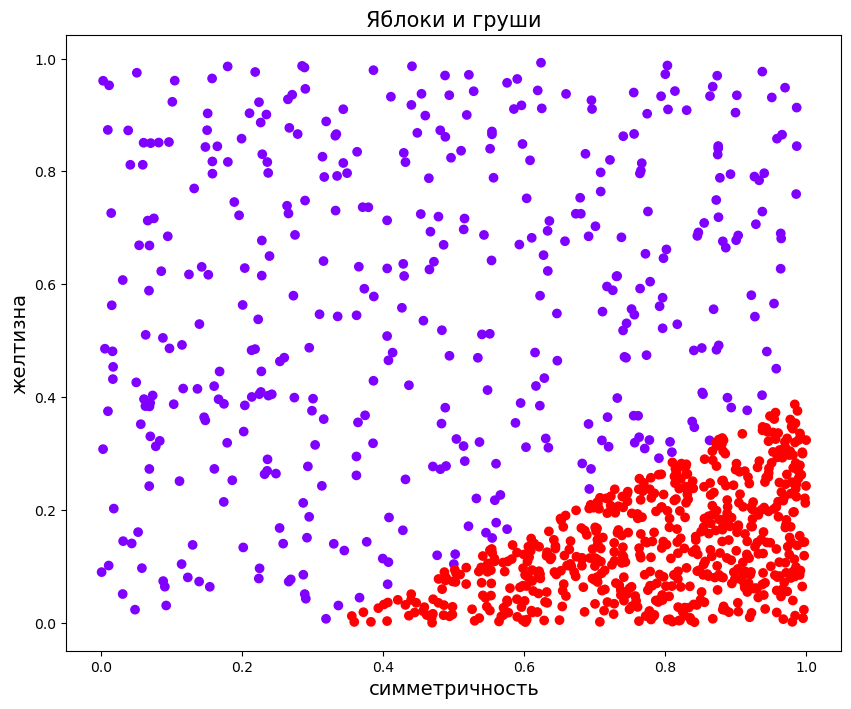

In [52]:
data = pd.read_csv("./data/apples_pears.csv")
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['target'], cmap='rainbow')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

In [53]:
X = data.iloc[:,:2].values  # матрица объекты-признаки
y = data['target'].values.reshape((-1, 1))  # классы (столбец из нулей и единиц)

Выведите лосс при обучении нейрона с ReLU на этом датасете:

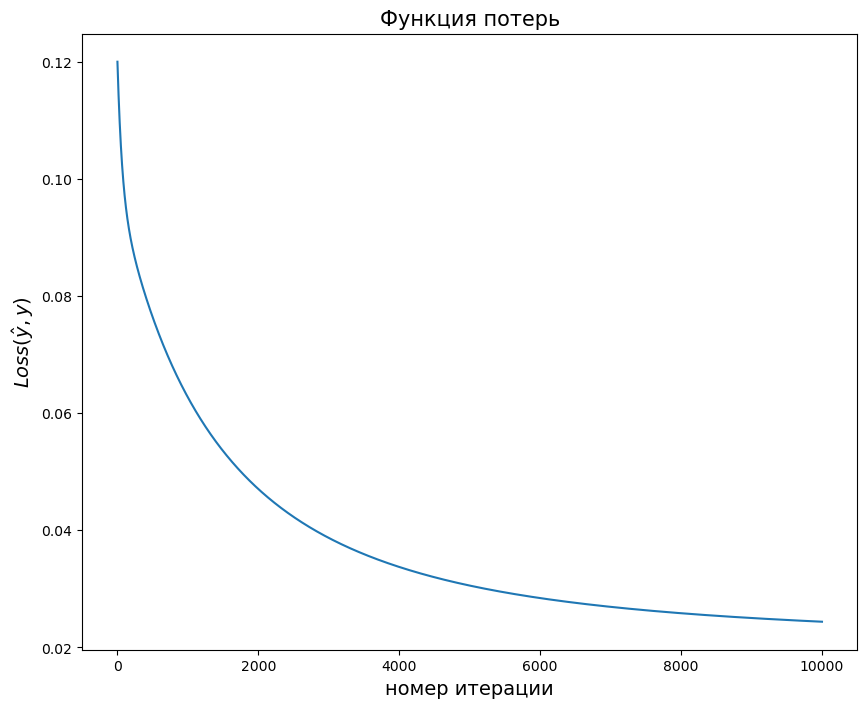

CPU times: total: 6.17 s
Wall time: 6.98 s


In [54]:
%%time

neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)
plt.show()

Скорее всего сейчас у вас лосс -- это прямая линия, и вы видите, что веса не обновляются. Но почему?

Всё просто -- если присмотреться, то видно, что self.w и self.b иницилизируются нулями в начале `.fit()`-метода. Если расписать, как будет идти обновление, то видно, что из-за ReLU веса просто-напросто не будут обновляться, если начать с инициализации нулями.

Это -- одна из причин, по которой в нейронных сетях веса инициализируют случайными числами (обычно из отрезка [0, 1)).

Обучим нейрон, инициализировав случайно веса (поставьте 10000 итераций).

**!!! Закомментируйте инициализацию нулями в функции `.fit()` класса `NeuronReLU` !!!**

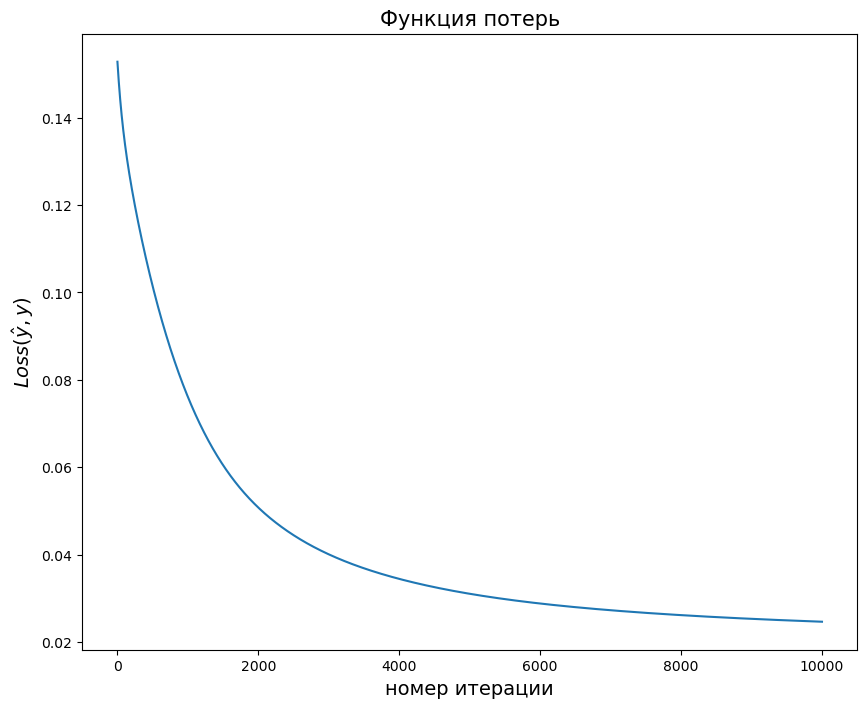

CPU times: total: 6.33 s
Wall time: 6.89 s


In [55]:
%%time

neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)
plt.show()

Посмотрим, как предсказывает этот нейрон:

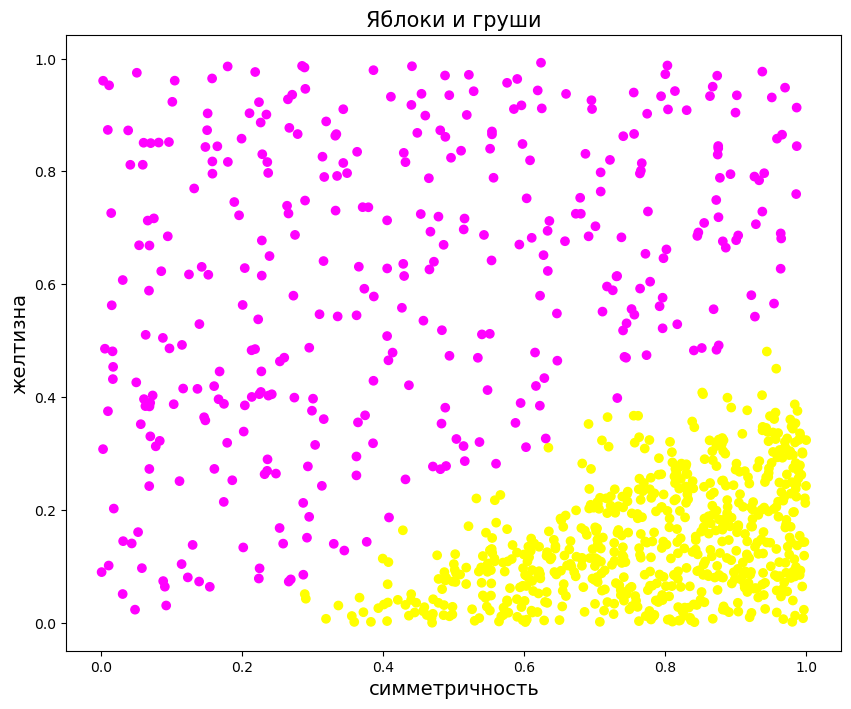

In [56]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=np.array(neuron.forward_pass(X) > 0.5).ravel(), cmap='spring')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

Есть одна тенденция: пороговая функция активации и сигмоида (обычно всё же только сигмоида) чаще используются именно на **выходном слое** нейросети в задаче классификации -- ими предсказывают вероятности объектов принадлежать одному из классов, в то время как продвинутые функции активации (ReLU и те, что будут дальше) используются внутри нейросети, то есть в **скрытых слоях**.

Нужно понимать, что ReLU не может вернуть отрицательные числа.

**Плюсы ReLU:**

* дифференцируемая (с доопределением в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде

**Возможные минусы ReLU:**

* не центрирована около 0 (может мешать скорости сходимости)
* зануляет все отрицательные входы, тем самым веса у занулённых нейронов могут часто *не обновляться*, эту проблему иногда называют *мёртвые нейроны*

С последней проблемой можно побороться, а именно:

<h2 style="text-align: center;"><b>Нейрон с LeakyReLU (Leaky Recitified Linear Unit)</b></h2>  

LeakyReLU очень слабо отличается от ReLU, но часто помогает сети обучаться быстрее, поскольку нет проблемы "мёртвых нейронов":

\begin{equation*}
LeakyReLU(x) =
 \begin{cases}
   \alpha x, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
LeakyReLU'(x) =
 \begin{cases}
   \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим LeakyReLu в Loss:

$$
Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (LeakyReLU(w \cdot X_i) - y_i)^2 =
\begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha \cdot w \cdot X_i - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}
$$  

Формула для обновления весов при градиентном спуске:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   \alpha X_i^T (w \cdot X_i - y), &{w \cdot X_i \le 0}\\
    X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$


**Плюсы LeakyReLU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU

**Возможные минусы LeakyReLU:**

* не центрирована около 0 (может мешать скорости сходимсти)
* немного не устойчива к "шуму" (см. лекции Стэнфорда)

<h2 style="text-align: center;"><b>Нейрон с ELU (Exponential Linear Unit)</a></b></h2>  

ELU -- не так давно предложенная (в 2015 году) функция активации, которая, как говорят авторы статьи, лучше LeakyReLU. Вот формула ELU:

\begin{equation*}
ELU(\alpha, x) =
 \begin{cases}
   \alpha (e^x - 1), &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
ELU'(x) =
 \begin{cases}
   ELU(\alpha, x) + \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Здесь в производной использован постой трюк -- сделано $- \alpha + \alpha$, чтобы вычислять было проще.

График этой функции:

<img src="http://p0.ifengimg.com/pmop/2017/0907/A004001DD141881BFD8AD62E5D31028C3BE3FAD1_size14_w446_h354.png" width=500 height=400>

Подставим ELu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ELU(\alpha, w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha (e^{w \cdot X_i} - 1) - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

Здесь вам нужно выписать самим град спуск для весов. Брать производную "в лоб" некрасиво и неудобно. Нужно воспользоваться **правилом цепочки**, оно же **правило взятия производной сложной функции**:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   , &{w \cdot X_i \le 0}\\
   , &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

**Плюсы ELU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU
* более устойчива к "шуму" (см. лекции Стэнфорда)

**Возможные минусы ELU:**

* не очень хорошо центрирована около 0 (может мешать скорости сходимсти)
* вычислительно дольше, чем ReLU и LeakyReLU

---

И напоследок -- ещё интересные функции активации:

`SeLU()` и `Swish()`. Про них можно прочитать здесь: [SeLU](https://arxiv.org/pdf/1706.02515.pdf), [Swish](https://arxiv.org/pdf/1710.05941.pdf).

За функцию активации можно взять вообще почти любую функцию (которая, как вы полагаете, будет помогать обучению). Ещё больше функций активации вы можете [найти на википедии](https://en.wikipedia.org/wiki/Activation_function).

## Задание 3. Нейрон с различными функциями активации

Реализуйте предыдущее задание с помощью функций активации LeakyReLU и ELU. Сравните результаты

In [58]:
def leaky_relu(x, alpha=0.01):
    """LeakyReLU: alpha*x при x<0, x при x>=0"""
    return np.where(x >= 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    """производная LeakyReLU: alpha при x<0, 1 при x>=0"""
    return np.where(x >= 0, 1.0, alpha)

class NeuronLeakyReLU:
    def __init__(self, w=None, b=0, alpha=0.01):
        self.w = w
        self.b = b
        self.alpha = alpha

    def activate(self, x):
        return leaky_relu(x, self.alpha)

    def forward_pass(self, X):
        z = np.dot(X, self.w) + self.b
        return self.activate(z)

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        n = len(y)
        y = np.array(y).reshape(-1, 1)
        z = np.dot(X, self.w) + self.b
        grad_act = leaky_relu_derivative(z, self.alpha)   # (n,1)
        error = y_pred - y
        dw = (1.0/n) * np.dot(X.T, error * grad_act)
        db = (1.0/n) * np.sum(error * grad_act)
        self.w -= learning_rate * dw
        self.b -= learning_rate * db

    def fit(self, X, y, num_epochs=300, learning_rate=0.005):
        if self.w is None:
            self.w = np.random.randn(X.shape[1], 1) * 0.01
        if self.b is None:
            self.b = 0.0
        losses = []
        for epoch in range(num_epochs):
            y_pred = self.forward_pass(X)
            losses.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred, learning_rate)
        return losses

In [59]:
def elu(x, alpha=1.0):
    """ELU: alpha*(exp(x)-1) при x<=0, x при x>0"""
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=1.0):
    """Производная ELU: a+alpha при x<=0, 1 при x>0, где a = elu(x)"""
    a = elu(x, alpha)
    return np.where(x > 0, 1.0, a + alpha)

class NeuronELU:
    def __init__(self, w=None, b=0, alpha=1.0):
        self.w = w
        self.b = b
        self.alpha = alpha   # параметр α (обычно 1)

    def activate(self, x):
        return elu(x, self.alpha)

    def forward_pass(self, X):
        z = np.dot(X, self.w) + self.b
        return self.activate(z)

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        n = len(y)
        y = np.array(y).reshape(-1, 1)
        z = np.dot(X, self.w) + self.b
        grad_act = elu_derivative(z, self.alpha)   # (n,1)
        error = y_pred - y
        dw = (1.0/n) * np.dot(X.T, error * grad_act)
        db = (1.0/n) * np.sum(error * grad_act)
        self.w -= learning_rate * dw
        self.b -= learning_rate * db

    def fit(self, X, y, num_epochs=300, learning_rate=0.005):
        if self.w is None:
            self.w = np.random.randn(X.shape[1], 1) * 0.01
        if self.b is None:
            self.b = 0.0
        losses = []
        for epoch in range(num_epochs):
            y_pred = self.forward_pass(X)
            losses.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred, learning_rate)
        return losses

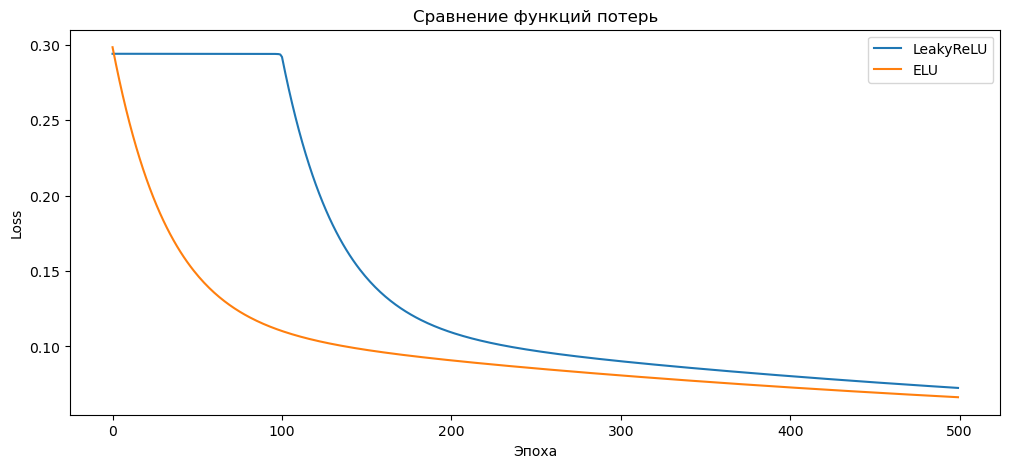

In [60]:
# Загрузка данных
data = pd.read_csv("./data/apples_pears.csv")
X = data.iloc[:,:2].values
y = data['target'].values.reshape(-1,1)

# Обучение нейрона с LeakyReLU
neuron_lrelu = NeuronLeakyReLU(alpha=0.01)
losses_lrelu = neuron_lrelu.fit(X, y, num_epochs=500, learning_rate=0.01)

# Обучение нейрона с ELU
neuron_elu = NeuronELU(alpha=1.0)
losses_elu = neuron_elu.fit(X, y, num_epochs=500, learning_rate=0.01)

# Сравнение графиков потерь
plt.figure(figsize=(12,5))
plt.plot(losses_lrelu, label='LeakyReLU')
plt.plot(losses_elu, label='ELU')
plt.legend()
plt.title('Сравнение функций потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.show()

## Задание 4. Сравнение собственной реализации с библиотечной

Сравните качество работы Вашего персептрона (с любой функцией активации) и алгоритма из библиотеки `sklearn` на датасете с сайта [Kaggle](https://www.kaggle.com) - [Gender Recognition by Voice](https://www.kaggle.com/primaryobjects/voicegender). (Код можно взять из файла Introducing_Scikit_Learn). Можно доработать собственную реализацию персептрона, сделав из него многослойный персептрон.

In [71]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

class CustomMLP:
    def __init__(self, input_size, hidden_size=50, learning_rate=0.01, n_epochs=300, verbose=True):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.verbose = verbose
        
        # Инициализация весов (He initialization для ReLU)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, 1))
        
    def _relu(self, z):
        return np.maximum(0, z)
    
    def _relu_derivative(self, z):
        return (z > 0).astype(float)
    
    def _sigmoid(self, z):
        z_clipped = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z_clipped))
    
    def _sigmoid_derivative(self, a):
        return a * (1 - a)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self._relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self._sigmoid(self.z2)
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        # Преобразуем y_true в numpy и приводим к форме (n_samples, 1)
        y_true = np.array(y_true).reshape(-1, 1)
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def backward(self, X, y_true, y_pred):
        m = X.shape[0]
        # Преобразуем y_true в numpy и приводим к форме (n_samples, 1)
        y_true = np.array(y_true).reshape(-1, 1)
        
        dZ2 = y_pred - y_true
        dW2 = (1/m) * np.dot(self.a1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self._relu_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
    
    def fit(self, X, y):
        # Преобразуем y в numpy (на всякий случай)
        y = np.array(y).reshape(-1, 1)
        losses = []
        for epoch in range(self.n_epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)
            self.backward(X, y, y_pred)
            if self.verbose and (epoch % 50 == 0 or epoch == self.n_epochs-1):
                print(f"Epoch {epoch:3d}/{self.n_epochs}, Loss: {loss:.6f}")
        return losses
    
    def predict(self, X):
        y_pred = self.forward(X)
        return (y_pred >= 0.5).astype(int).flatten()
    
    def predict_proba(self, X):
        return self.forward(X).flatten()

# создание и обучение собственной модели
custom_mlp = CustomMLP(input_size=X_train.shape[1], hidden_size=100, learning_rate=0.01, n_epochs=300, verbose=True)
start_time = time.time()
custom_mlp.fit(X_train, y_train)
train_time_custom = time.time() - start_time

y_pred_custom = custom_mlp.predict(X_test)
y_proba_custom = custom_mlp.predict_proba(X_test)

# обучение MLPClassifier из sklearn
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=300,
    random_state=RANDOM_STATE,
    verbose=True
)

start_time = time.time()
sklearn_mlp.fit(X_train, y_train)
train_time_sklearn = time.time() - start_time

y_pred_sklearn = sklearn_mlp.predict(X_test)
y_proba_sklearn = sklearn_mlp.predict_proba(X_test)[:, 1]

def evaluate_model(y_true, y_pred, y_proba, model_name):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

results_custom = evaluate_model(y_test, y_pred_custom, y_proba_custom, 'Custom MLP')
results_sklearn = evaluate_model(y_test, y_pred_sklearn, y_proba_sklearn, 'Sklearn MLP')

results_df = pd.DataFrame([results_custom, results_sklearn])

Epoch   0/300, Loss: 1.947029
Epoch  50/300, Loss: 1.124271
Epoch 100/300, Loss: 1.559474
Epoch 150/300, Loss: 0.750841
Epoch 200/300, Loss: 0.834710
Epoch 250/300, Loss: 0.699653
Epoch 299/300, Loss: 0.652929
Iteration 1, loss = 2.04518880
Iteration 2, loss = 0.67956641
Iteration 3, loss = 0.66243551
Iteration 4, loss = 0.65530967
Iteration 5, loss = 0.65156443
Iteration 6, loss = 0.64623507
Iteration 7, loss = 0.64060960
Iteration 8, loss = 0.63572393
Iteration 9, loss = 0.63287388
Iteration 10, loss = 0.62601736
Iteration 11, loss = 0.62342084
Iteration 12, loss = 0.62023730
Iteration 13, loss = 0.61627340
Iteration 14, loss = 0.61408531
Iteration 15, loss = 0.60937057
Iteration 16, loss = 0.60537522
Iteration 17, loss = 0.60292229
Iteration 18, loss = 0.60042212
Iteration 19, loss = 0.59696914
Iteration 20, loss = 0.59610122
Iteration 21, loss = 0.59241111
Iteration 22, loss = 0.58944051
Iteration 23, loss = 0.58678152
Iteration 24, loss = 0.58675554
Iteration 25, loss = 0.58386340

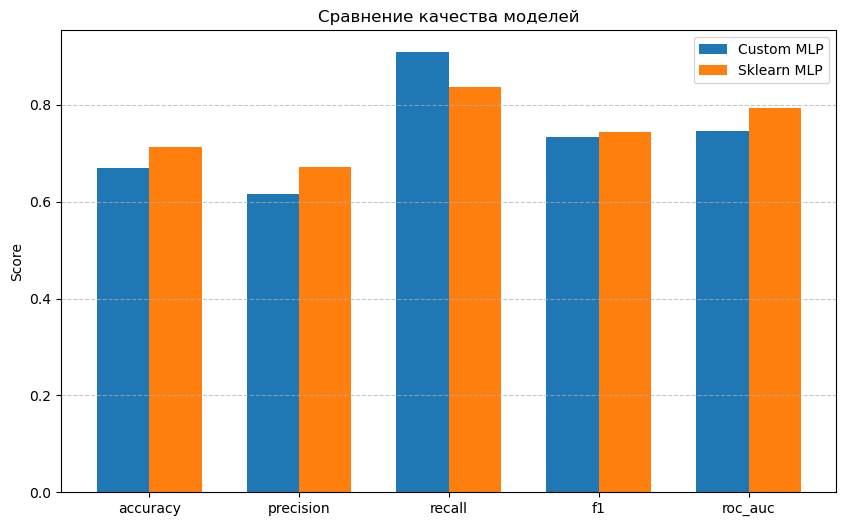

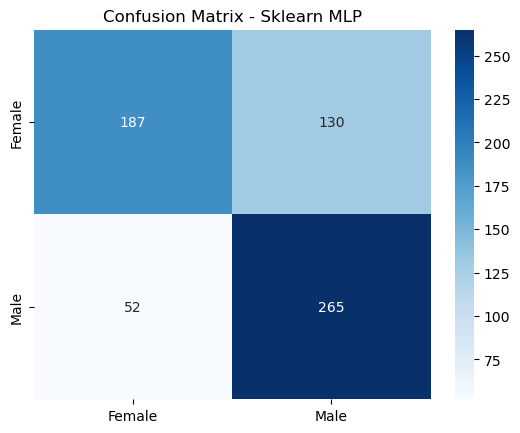

In [72]:
# сравнение метрик
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
custom_scores = [results_custom[m] for m in metrics]
sklearn_scores = [results_sklearn[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, custom_scores, width, label='Custom MLP')
ax.bar(x + width/2, sklearn_scores, width, label='Sklearn MLP')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Сравнение качества моделей')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# матрица ошибок для лучшей модели
cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix - Sklearn MLP')
plt.show()

<h3 style="text-align: center;"><b>Полезные ссылки</b></h3>

0). Статья от Стэнфорда: http://cs231n.github.io/neural-networks-1/

1). Хорошая статья про функции активации: https://www.jeremyjordan.me/neural-networks-activation-functions/

2). [Видео от Siraj Raval](https://www.youtube.com/watch?v=-7scQpLossT7uo)

3). Современная статья про функции активации. Теперь на хайпе активация $swish(x) = x\sigma (\beta x)$: https://arxiv.org/pdf/1710.05941.pdf (кстати, при её поиске в некоторой степени использовался neural architecture search)

4). SeLU имеет очень интересные, доказанные с помощью теории вероятностей свойства: https://arxiv.org/pdf/1706.02515.pdf (да, в этой статье 102 страницы)

5). [Список функций активации из википедии](https://en.wikipedia.org/wiki/Activation_function)